### https://scikit-learn.org/stable/user_guide.html

### Data loading

In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('seattle-weather.csv')

In [4]:
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


### Look into the data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [6]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [7]:
import matplotlib.pyplot as plt


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(array([ 94.,  23., 885.,  76.,  73., 104.,  78.,  76.,  39.,  13.]),
 array([-1.2039728 , -0.68121909, -0.15846537,  0.36428835,  0.88704207,
         1.40979579,  1.93254951,  2.45530322,  2.97805694,  3.50081066,
         4.02356438]),
 <BarContainer object of 10 artists>)

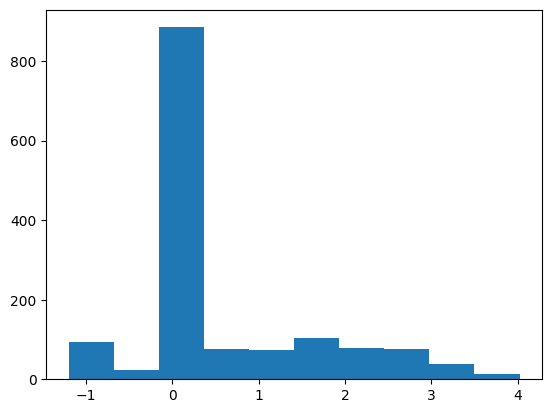

In [13]:
plt.hist(np.where(df['precipitation'] == 0, 0, np.log(df['precipitation'])))

<Axes: >

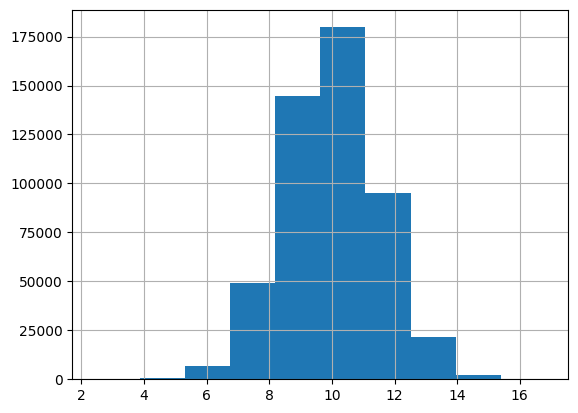

In [11]:
pd.Series(np.random.normal(10,1.5,500000)).hist()

### Data preparation

In [14]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [15]:
df['weather'].nunique()

5

In [16]:
df['date'] = pd.to_datetime(df['date'])

In [17]:
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

In [18]:
df = df.drop(['date','weather'], axis=1)

In [19]:
df.head()

,precipitation,temp_max,temp_min,wind,month,quarter
0,0.0,12.8,5.0,4.7,1,1
1,10.9,10.6,2.8,4.5,1,1
2,0.8,11.7,7.2,2.3,1,1
3,20.3,12.2,5.6,4.7,1,1
4,1.3,8.9,2.8,6.1,1,1


### Model construction

#### Features and target separation

In [20]:
X = df.drop('wind',axis=1)
Y = df['wind']

#### Train / Test split

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.15)

In [25]:
X_train.head(3)

,precipitation,temp_max,temp_min,month,quarter
1233,0.0,25.6,12.2,5,2
730,0.5,8.3,5.0,12,4
1038,4.1,14.4,10.6,11,4


In [26]:
Y_train.head(3)

,wind
1233,3.0
730,1.7
1038,3.3


#### Model selection and training(FIT)

In [24]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [28]:
model.coef_

array([ 0.06375666, -0.04364932,  0.04119223,  0.0755514 , -0.31974287])

In [29]:
model.intercept_

3.758445349017972

In [30]:
predict = model.predict(X_test)

In [31]:
predict

array([2.72942461, 3.19403366, 3.20504712, 5.44197359, 3.62825562,
       4.08561362, 4.55320094, 2.9216695 , 3.9949372 , 3.01538602,
       3.23300477, 3.13913955, 3.3810835 , 3.4696889 , 3.31707186,
       2.88926714, 3.10993704, 3.46757245, 2.85448225, 4.04494847,
       2.58846612, 3.2362034 , 4.35373419, 3.72925295, 2.50885668,
       3.08655743, 3.21046016, 3.97493416, 3.78010946, 3.47711837,
       3.1481052 , 3.0166062 , 2.64053073, 3.10966846, 2.93175263,
       3.40507284, 2.94145093, 3.79131501, 2.90408878, 3.45424487,
       2.85896521, 3.16491189, 3.34549579, 3.2946373 , 3.10715354,
       2.94685891, 2.92874294, 2.88472989, 3.19592073, 5.14997931,
       3.0469429 , 3.19321793, 2.78843794, 2.93162593, 2.88504514,
       3.04606123, 2.96033813, 2.83432809, 2.85854029, 3.33308877,
       3.18768563, 3.20267388, 5.19172153, 2.90832701, 3.33270292,
       3.30419638, 2.60777586, 3.40446567, 2.81888015, 3.07567638,
       2.85742977, 2.97010097, 4.64418521, 2.81888015, 2.63795

#### Quality check

In [32]:
from sklearn.metrics import mean_absolute_error

In [33]:
mean_absolute_error(Y_test, predict)

1.0986969608320407

In [34]:
mean_absolute_error(Y_test, predict) / np.mean(Y_test)

0.3530723508370567

#### Polynomial

In [36]:
from sklearn.preprocessing import PolynomialFeatures

In [37]:
poly = PolynomialFeatures(3)

In [38]:
poly_X = poly.fit_transform(X)

In [39]:
X.shape

(1461, 5)

In [41]:
poly_X.shape

(1461, 56)

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(poly_X,Y, test_size=0.15)
model = LinearRegression()
model.fit(X_train, Y_train)
predict = model.predict(X_test)
mean_absolute_error(Y_test,predict)

2.0471985175392846